# Car Paint Defect Detection — YOLOv8 训练

**使用说明（上传到 Kaggle 前先做）：**
1. Kaggle → Datasets → New Dataset，上传整个 `final year car paint defect.v1i.yolov8/` 文件夹
2. 新建 Notebook，右侧 Add Data 添加刚才的数据集
3. 右侧 Session options → Accelerator 选 **GPU P100**
4. 粘贴本 Notebook 内容，依次运行

## 1. 确认环境与数据集路径

In [3]:
import os
import glob

# 查看 Kaggle 挂载的数据集
!ls /kaggle/input/

# 找到数据集根目录（会自动识别）
candidates = glob.glob('/kaggle/input/**/data.yaml', recursive=True)
print('找到 data.yaml:', candidates)
DATASET_ROOT = os.path.dirname(candidates[0])
print('数据集根目录:', DATASET_ROOT)

datasets
找到 data.yaml: ['/kaggle/input/datasets/alaskayang/final-year-car-paint-defect-v1i-yolov8/data.yaml']
数据集根目录: /kaggle/input/datasets/alaskayang/final-year-car-paint-defect-v1i-yolov8


## 2. 安装 Ultralytics

In [4]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6717.7/8062.4 GB disk)


## 3. 修正 data.yaml 路径

原始 data.yaml 使用相对路径，Kaggle 环境需要改为绝对路径。

In [5]:
import yaml
import shutil

# 读取原始 yaml
with open(os.path.join(DATASET_ROOT, 'data.yaml'), 'r') as f:
    data = yaml.safe_load(f)

print('原始内容:', data)

# 改为绝对路径，复制到可写目录
data['train'] = os.path.join(DATASET_ROOT, 'train', 'images')
data['val']   = os.path.join(DATASET_ROOT, 'valid', 'images')
data['test']  = os.path.join(DATASET_ROOT, 'test',  'images')

YAML_PATH = '/kaggle/working/data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print('\n修正后内容:')
with open(YAML_PATH) as f:
    print(f.read())

原始内容: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['dirt', 'runs', 'scratch', 'water marks'], 'roboflow': {'workspace': 'poli-h7nww', 'project': 'final-year-car-paint-defect', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/poli-h7nww/final-year-car-paint-defect/dataset/1'}}

修正后内容:
names:
- dirt
- runs
- scratch
- water marks
nc: 4
roboflow:
  license: CC BY 4.0
  project: final-year-car-paint-defect
  url: https://universe.roboflow.com/poli-h7nww/final-year-car-paint-defect/dataset/1
  version: 1
  workspace: poli-h7nww
test: /kaggle/input/datasets/alaskayang/final-year-car-paint-defect-v1i-yolov8/test/images
train: /kaggle/input/datasets/alaskayang/final-year-car-paint-defect-v1i-yolov8/train/images
val: /kaggle/input/datasets/alaskayang/final-year-car-paint-defect-v1i-yolov8/valid/images



## 4. 开始训练

| 模型 | 参数量 | 速度 | 精度 | 推荐场景 |
|------|--------|------|------|----------|
| yolov8n | 3.2M | 最快 | 一般 | 快速验证 |
| yolov8s | 11.2M | 快 | 较好 | **毕设推荐** |
| yolov8m | 25.9M | 中等 | 好 | 精度优先 |

In [6]:
from ultralytics import YOLO

# 加载预训练权重（自动从官网下载，约 22MB）
model = YOLO('yolov8s.pt')

# 开始训练
results = model.train(
    data=YAML_PATH,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,           # GPU
    project='/kaggle/working/runs',
    name='car_defect',
    patience=20,        # 20轮无提升则早停
    save=True,
    plots=True,         # 生成训练曲线图
    val=True,
)

print('训练完成！')
print('最优权重路径:', results.save_dir)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_defect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pe

## 5. 在测试集上评估

In [7]:
import os

best_weights = os.path.join(results.save_dir, 'weights', 'best.pt')
model_best = YOLO(best_weights)

# 在测试集上计算 mAP
metrics = model_best.val(
    data=YAML_PATH,
    split='test',
    device=0,
)

print(f"\n测试集结果：")
print(f"  mAP@50    : {metrics.box.map50:.4f}")
print(f"  mAP@50-95 : {metrics.box.map:.4f}")
print(f"  Precision  : {metrics.box.mp:.4f}")
print(f"  Recall     : {metrics.box.mr:.4f}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.1 ms, read: 4.1±1.0 MB/s, size: 27.1 KB)
val: Scanning /kaggle/input/datasets/alaskayang/final-year-car-paint-defect-v1i-yolov8/test/labels... 34 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 34/34 282.4it/s 0.1s.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/alaskayang/final-year-car-paint-defect-v1i-yolov8/test is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 92, len(boxes) = 148. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.6it/s 1.1s0.9s
                   a

## 6. 可视化预测结果


0: 640x640 2 scratchs, 9.5ms
1: 640x640 5 scratchs, 9.5ms
2: 640x640 1 scratch, 9.5ms
3: 640x640 5 dirts, 1 scratch, 9.5ms
4: 640x640 2 dirts, 1 scratch, 9.5ms
5: 640x640 4 dirts, 1 scratch, 9.5ms
Speed: 2.0ms preprocess, 9.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/predict


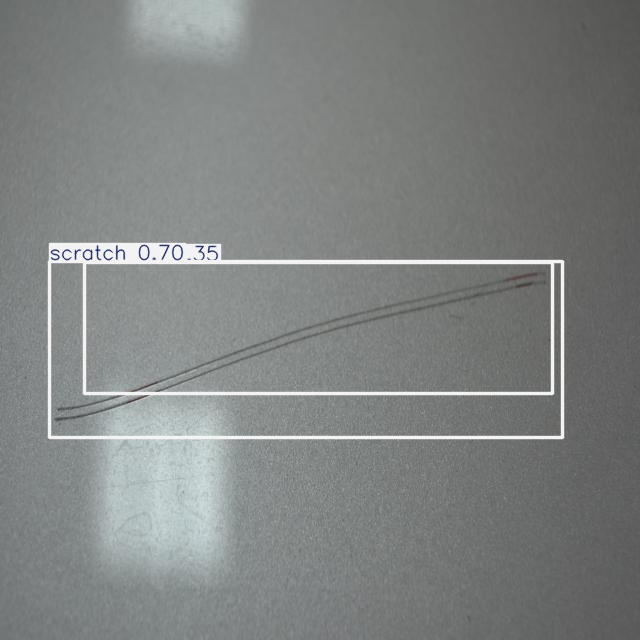

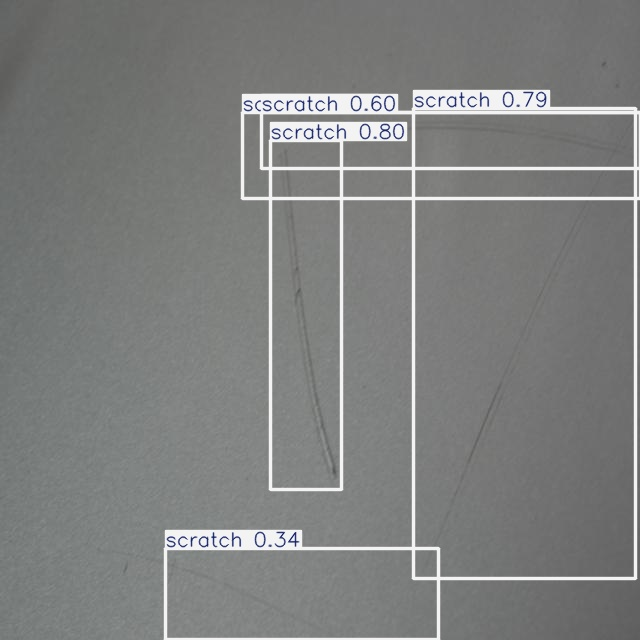

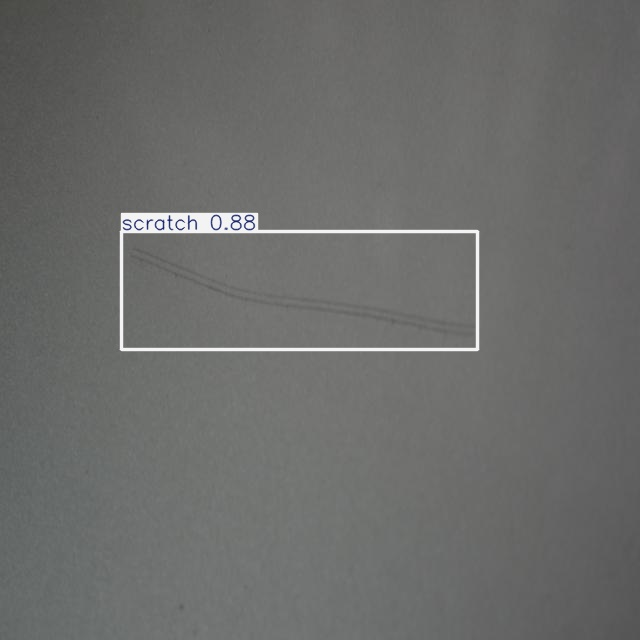

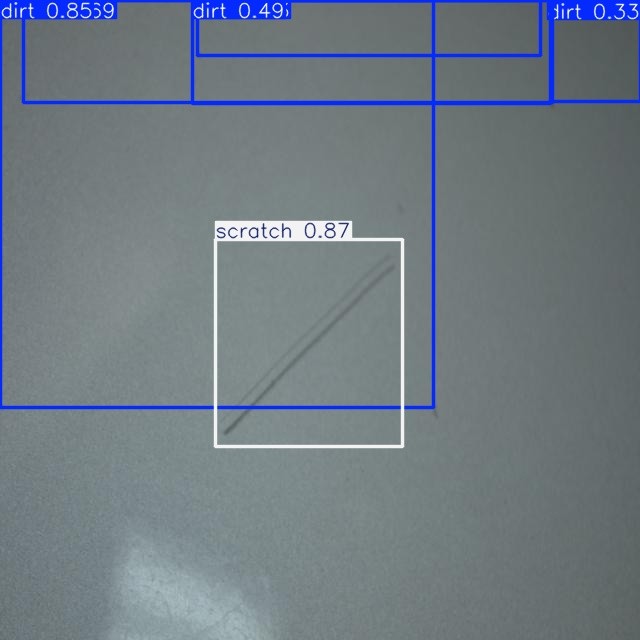

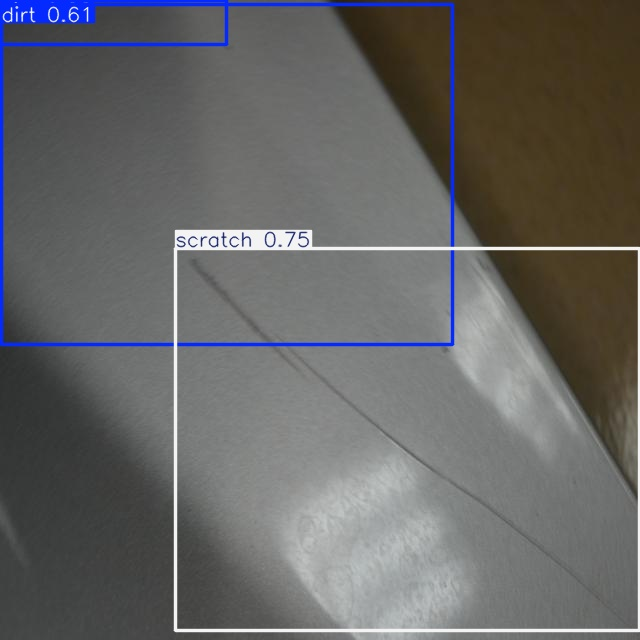

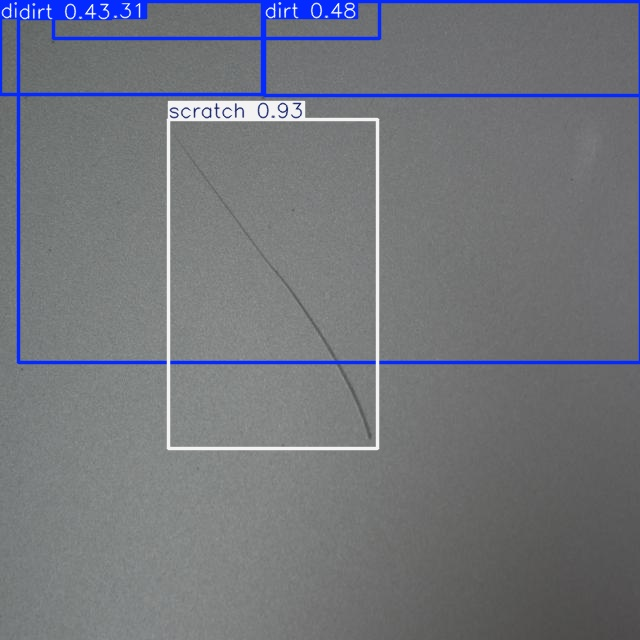

In [8]:
import glob
from IPython.display import Image, display

# 对测试集前 6 张图进行预测
test_images = sorted(glob.glob(os.path.join(DATASET_ROOT, 'test', 'images', '*.jpg')))[:6]

pred_results = model_best.predict(
    source=test_images,
    conf=0.25,
    save=True,
    project='/kaggle/working/runs',
    name='predict',
)

# 显示预测图
pred_imgs = sorted(glob.glob('/kaggle/working/runs/predict/*.jpg'))
for p in pred_imgs:
    display(Image(filename=p, width=640))

## 7. 打包下载结果

运行后在 Kaggle 右侧 Output 面板下载 `results.zip`

In [9]:
import shutil

# 复制最优权重到输出根目录方便下载
shutil.copy(best_weights, '/kaggle/working/best.pt')

# 打包训练结果（曲线图、权重等）
shutil.make_archive('/kaggle/working/results', 'zip', results.save_dir)

print('可下载文件：')
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}') / 1024 / 1024
    print(f'  {f}  ({size:.1f} MB)')

可下载文件：
  yolov8s.pt  (21.5 MB)
  best.pt  (21.5 MB)
  yolo26n.pt  (5.3 MB)
  .virtual_documents  (0.0 MB)
  runs  (0.0 MB)
  results.zip  (45.0 MB)
  data.yaml  (0.0 MB)
